In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

In [62]:
def generate_data(sigma_sq):
    # Paramètres du dataset
    n_samples = 125
    mu2 = np.array([-1, 0])
    mu1 = np.array([1, 0])
    cov = np.eye(2) * sigma_sq
    #to conserve de data distrubution each time
    np.random.seed(42)
    # Génération des données selon une loi normale
    X1 = np.random.multivariate_normal(mu1, cov, n_samples)
    y1 = np.zeros(n_samples) # Classe 0

    X2 = np.random.multivariate_normal(mu2, cov, n_samples)
    y2 = np.ones(n_samples)  # Classe 1

    # Fusion et mélange (Shuffling)
    X = np.vstack((X1, X2))
    y = np.hstack((y1, y2))
    return shuffle(X, y, random_state=42)

In [63]:
# Splitting (80% train, 20% test)
def split_data(X, y):
    return train_test_split(X, y, test_size=0.2, random_state=42)

##Implementing the plot function to visualize the dataset


In [66]:

def plot_data(X, y,sigma):

 plt.figure(figsize=(9, 5))
 # Plot data for Class 0
 plt.scatter(X[y == 0, 0], X[y == 0, 1], label='Classe 0', alpha=0.7, c='red')

 # Plot data for Class 1
 plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Classe 1', alpha=0.7, c='blue')

 plt.title(f'Distribution des données (sigma:{sigma})')
 plt.xlabel('Feature 1')
 plt.ylabel('Feature 2')
 plt.legend()
 plt.grid(True)
 plt.show()

## Generate and Plot Data (Sigma=0.25)




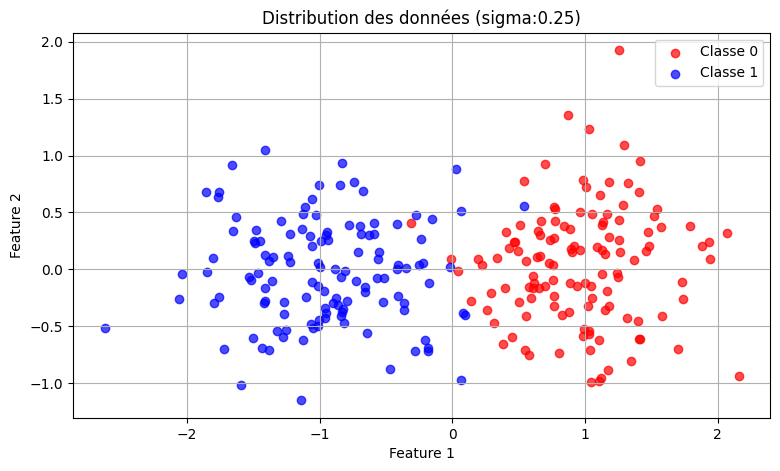

In [70]:
X,y = generate_data(0.25)
plot_data(X,y,0.25)



## Generate and Plot Data (Sigma=0.75) :

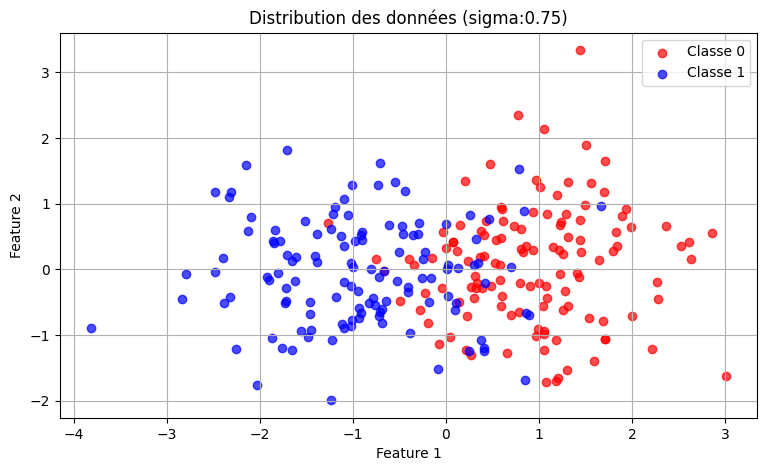

In [72]:
X,y = generate_data(0.75)
plot_data(X,y,0.75)



##Activation function

In [73]:
def acti_func(z):
  if z > 0:
        return 1
  else:
        return 0

## Perceptron function




In [23]:
def perceptron(X, y, lr, epochs):
    # m: nombre d'exemples, n: nombre de features
    m, n = X.shape

    # Initialisation des poids (n+1 pour inclure le biais w0)
    w = np.zeros((n + 1, 1))
    n_miss_list = []

    for epoch in range(epochs):
        n_miss = 0
        for idx, x_i in enumerate(X):
            # Insertion de 1 pour le biais (X0 = 1)
            x_i = np.insert(x_i, 0, 1).reshape(-1, 1)

            # Calcul de la prédiction (Hypothèse)
            y_hat = acti_func(np.dot(x_i.T, w))

            # Mise à jour des poids si l'exemple est mal classé
            # Règle du Perceptron : w = w + lr * (y - y_hat) * x
            error = y[idx] - y_hat
            if error != 0:
                w += lr * error * x_i
                n_miss += 1

        n_miss_list.append(n_miss)

    return w, n_miss_list



##Perceptron function avec w en parametrers :

In [92]:
def perceptron_random_w(X, y, lr, epochs,facteur):    # m: nombre d'exemples, n: nombre de features
    m, n = X.shape

    n_miss_list = []

    w = np.random.randn(n + 1, 1) * facteur

    for epoch in range(epochs):
        n_miss = 0
        for idx, x_i in enumerate(X):
            # Insertion de 1 pour le biais (X0 = 1)
            x_i = np.insert(x_i, 0, 1).reshape(-1, 1)

            # Calcul de la prédiction (Hypothèse)
            y_hat = acti_func(np.dot(x_i.T, w))

            # Mise à jour des poids si l'exemple est mal classé
            # Règle du Perceptron : w = w + lr * (y - y_hat) * x
            error = y[idx] - y_hat
            if error != 0:
                w += lr * error * x_i
                n_miss += 1

        n_miss_list.append(n_miss)

    return w, n_miss_list



##Decision boundery plot function

In [89]:
def plot_decision_boundary(X, y, w):
    """
    Trace la limite de décision.
    L'équation est : w0 + w1*x1 + w2*x2 = 0
    D'où : x2 = -(w1/w2)*x1 - (w0/w2)
    """
    # Points pour la ligne
    x1 = np.array([min(X[:, 0]), max(X[:, 0])])

    # Calcul de la pente (m) et de l'ordonnée à l'origine (c)
    m = -w[1] / w[2]
    c = -w[0] / w[2]

    x2 = m * x1 + c

    # Affichage
    plt.figure(figsize=(7, 5))
    # Plot data for Class 0
    plt.scatter(X[y == 0, 0], X[y == 0, 1], label='Classe 0', alpha=0.7, c='red')

    # Plot data for Class 1
    plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Classe 1', alpha=0.7, c='blue')


    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

    plt.plot(x1, x2, color='brown', label='Frontière de décision')
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

#Accuracy function :

In [96]:
def evaluate_perceptron(X_test, y_test, w):


    # 1. Ajouter le biais (colonne de 1)
    X_test_augmented = np.insert(X_test, 0, 1, axis=1)

    # 2. Calculer le produit entre X et les poids
    z = np.dot(X_test_augmented, w)

    # 3. Appliquer la fonction d'activation à chaque valeur
    y_pred = np.array([acti_func(val) for val in z])

    # 4. Calculer l'accuracy
    accuracy = np.sum(y_pred == y_test) / len(y_test)

    return accuracy

#Experience N°1 : (sigma = 0.25)

###a - L'algorithme converge-t-il ? Pourquoi ?

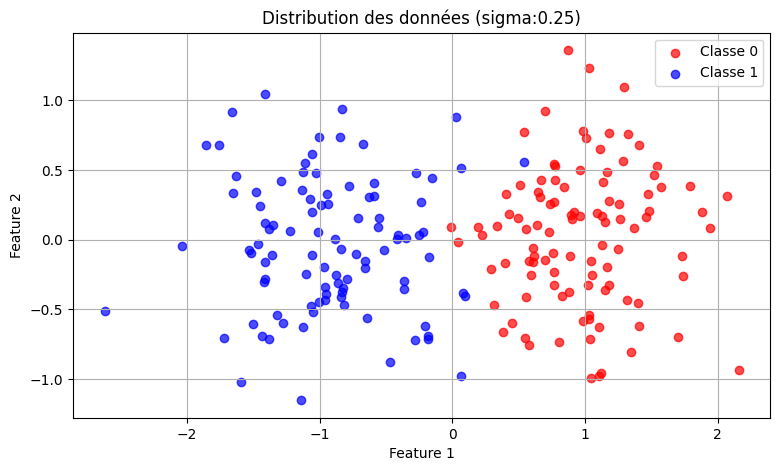

In [79]:

#Donnés de entrainement
X,y = generate_data(0.25)
X_train, X_test, y_train, y_test = split_data(X, y)
plot_data(X_train,y_train,0.25)


Oui l'algorithme converge car les donnes d'apres la figure sont lineairement separable

##b. Tracez la limite de décision trouvée par votre algorithme. Cette limite de décision est-elle unique ?

In [95]:
## Entraînement
w, errors = perceptron(X_train, y_train, lr=0.1, epochs=10)

print("Matrice des poids complète :")
print(w)

Matrice des poids complète :
[[ 0.        ]
 [-0.27254437]
 [-0.02827291]]


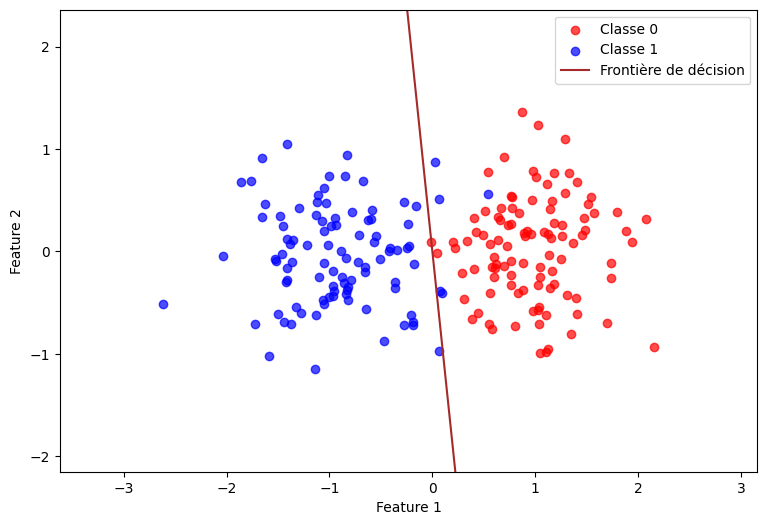

In [90]:
#Tracage du frontiere de decision
plot_decision_boundary(X_train,y_train,w)

Elle n’est pas nécessairement unique.Si les données sont séparables, il peut exister plusieurs lignes différentes qui classent correctement toutes les données.

Le perceptron va converger vers une solution correcte, mais cette solution dépend de l’initialisation des poids et de l’ordre des données pendant l’entraînement.

# b.  La modification de l'initialisation modifie-t-elle le résultat de l'algorithme ?
On va appeller la fonction perceptron_random_w() pour essayer une initialisaition differente pour les weights juste on a changer une ligne dans la fonction perceptron()
on changer w = np.zeros((n + 1, 1)) par w = np.random.rand(n + 1, 1)*facteur  avec facteur un nombre aleatoire choisi a l'avance

In [93]:
fact=5
w, errors = perceptron_random_w(X_train, y_train, lr=0.1, epochs=10,facteur=fact)

print("Matrice des poids complète :")
print(w)


Matrice des poids complète :
[[ 0.63088774]
 [-3.48676518]
 [-0.78211662]]


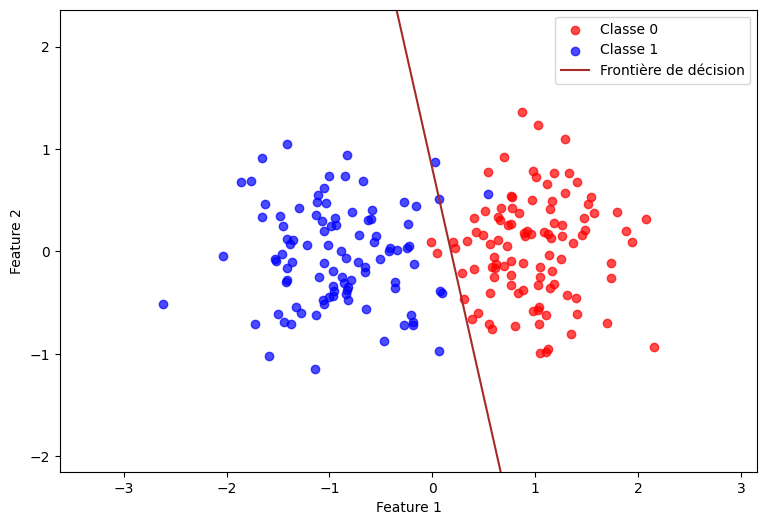

In [94]:
#Tracage du frontiere de decision sur les donnes de train
plot_decision_boundary(X_train,y_train,w)

n'est pas le meme frantiere trouver precedement

#c. Calculer la justesse (accuracy) de la classification sur l'ensemble de test. Tracez la limite de décision sur l'ensemble de test.

In [97]:
accuracy = evaluate_perceptron(X_test, y_test, w)
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 98.00%


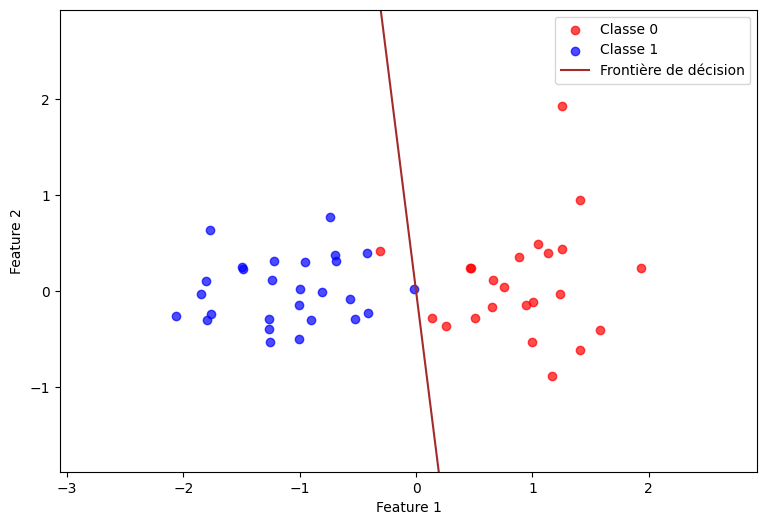

In [99]:
#Tracage du frontiere de decision sur les donnes de Test
plot_decision_boundary(X_test,y_test,w)

l'accuracy est presque 100%  , les donnes de tests sont bien separés , le perceptron est bien entrainés

#Expérience 2 : (sigma=0.75)

##d. L'algorithme converge-t-il ? Pourquoi ?

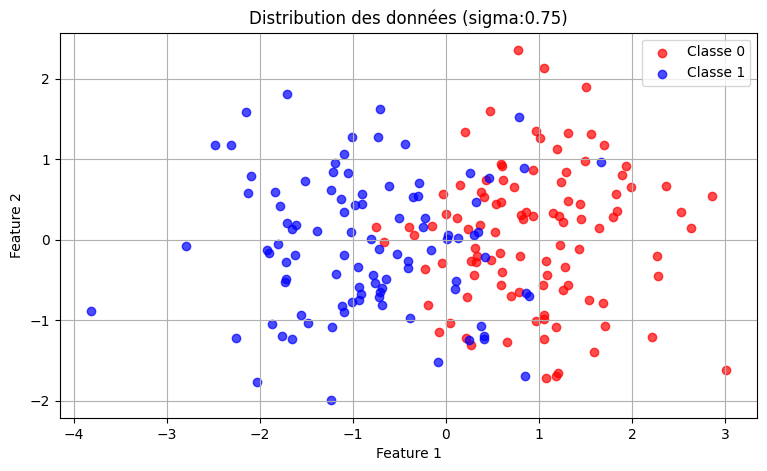

In [101]:

#Donnés de entrainement
X,y = generate_data(0.75)
X_train, X_test, y_train, y_test = split_data(X, y)
plot_data(X_train,y_train,0.75)


les données sont chevauchés , l'algorithme ne va pas converger car les donnes ne sont pas linéairement séparables

##e. Tracez la limite de décision trouvée par votre algorithme. Cette limite de décision est-elle unique ? La modification de l'initialisation modifie-t-elle le résultat de l'algorithme ?

In [112]:
## Entraînement
for i in range(60):
 w, errors = perceptron(X_train, y_train, lr=0.1, epochs=i)

 print("Matrice des poids complète :")
 print(w)

Matrice des poids complète :
[[0.]
 [0.]
 [0.]]
Matrice des poids complète :
[[-0.1       ]
 [-0.23751147]
 [-0.11018263]]
Matrice des poids complète :
[[ 0.        ]
 [-0.2530193 ]
 [-0.14326697]]
Matrice des poids complète :
[[ 0.        ]
 [-0.21148861]
 [-0.13325861]]
Matrice des poids complète :
[[-0.1       ]
 [-0.23098276]
 [-0.0693593 ]]
Matrice des poids complète :
[[ 0.        ]
 [-0.23062398]
 [-0.2220535 ]]
Matrice des poids complète :
[[ 0.        ]
 [-0.20387883]
 [-0.13908943]]
Matrice des poids complète :
[[ 0.        ]
 [-0.2227887 ]
 [-0.14670646]]
Matrice des poids complète :
[[ 0.        ]
 [-0.13988848]
 [-0.13016683]]
Matrice des poids complète :
[[ 0.        ]
 [-0.1473127 ]
 [-0.13941782]]
Matrice des poids complète :
[[ 0.        ]
 [-0.15473692]
 [-0.1486688 ]]
Matrice des poids complète :
[[ 0.        ]
 [-0.20838712]
 [-0.13512029]]
Matrice des poids complète :
[[-0.1       ]
 [-0.22788127]
 [-0.07122098]]
Matrice des poids complète :
[[ 0.        ]
 [-0.227

quelque soit la valeur du epochs les poids ne convergenet pas

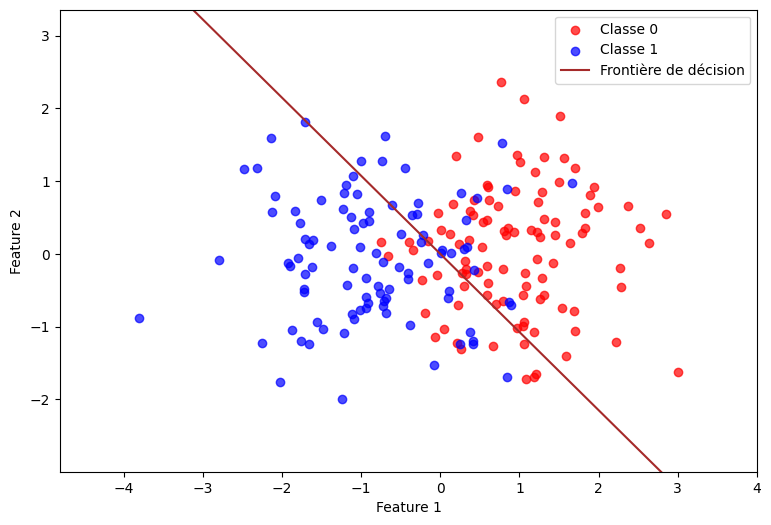

In [113]:
#Tracage du frontiere de decision sur les donnes de train
plot_decision_boundary(X_train,y_train,w)

les deux classes ne sont pas bien separes , et la modification de l'initialisation va changer la droites puisque elle  n'est pas unique

##f. Calculer la justesse (accuracy) de la classification sur l'ensemble de test. Tracez la limite de décision sur l'ensemble de test.

In [114]:
accuracy = evaluate_perceptron(X_test, y_test, w)
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 80.00%


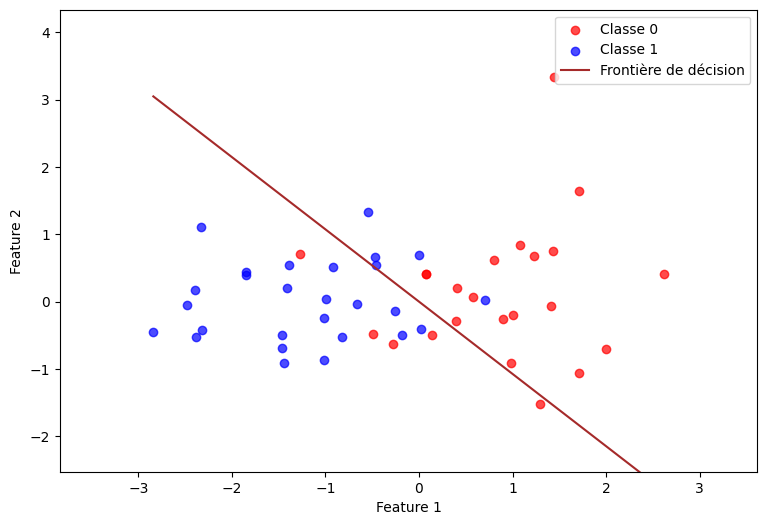

In [115]:
#Tracage du frontiere de decision sur les donnes de Test
plot_decision_boundary(X_test,y_test,w)

les resultats depend des nombres du epochs  , une mauvaise precision du au chevauchement du donnés de facon a etre non linéairement separable